# Micrograd Tensor Addition

## 1. Imports

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 2. Building out Tensor Class

In [ ]:
class Tensor:
  def __init__(self, data, _children=(), _op=''):
    self.data = np.array(data, dtype=np.float32)
    self.grad = np.zeros_like(self.data)
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op

  def __repr__(self):
    return f"Tensor({self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data + other.data, (self, other), "+")
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data * other.data, (self, other), "*")
    return out

  def __matmul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data @ other.data, (self, other), "@")
    return out

  def __neg__(self):
    return Tensor(self.data * -1, (self,), "neg")

  def __sub__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data - other.data, (self, other), "-")
    return out

  def __truediv__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data / other.data, (self, other), "/")
    return out

  def transpose(self):
    out = Tensor(self.data.T, (self,), "T")
    return out

In [ ]:
a = Tensor([1, 2, 3])

In [ ]:
b = Tensor([1, 2, 3])
a + b

Tensor([2. 4. 6.])

In [ ]:
c = Tensor([1])
a + c

Tensor([2. 3. 4.])

In [ ]:
a = Tensor([1, 2, 3])
b = Tensor([1, 2, 3])
c = Tensor([1, 2, 3])

d = (a + b) * c
d

Tensor([ 2.  8. 18.])

In [ ]:
from graphviz import Digraph
import numpy as np

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges


def _format_tensor_data(arr):
    """Formats 0D/1D/ND NumPy arrays cleanly for Graphviz record labels."""
    if arr is None:
        return "None"

    # 0D scalars or single-element arrays
    if arr.ndim == 0 or arr.size == 1:
        return f"{float(arr.squeeze()):.4f}"

    # Multi-element arrays: display shape and compact array values
    shape_str = f"shape {arr.shape}"
    arr_str = np.array2string(arr, precision=2, suppress_small=True, separator=', ')
    clean_arr = arr_str.replace('\n', ' ')  # avoid breaking Graphviz record lines
    return f"{shape_str} \\n {clean_arr}"


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))

        # Include label if available on the instance
        label_prefix = f"{n.label} | " if hasattr(n, 'label') and n.label else ""

        data_str = _format_tensor_data(n.data)
        grad_str = _format_tensor_data(n.grad)

        # Construct Graphviz record label
        node_label = f"{{{label_prefix}data: {data_str} | grad: {grad_str}}}"
        dot.node(name=uid, label=node_label, shape='record')

        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [ ]:
a = Tensor([1, 2, 3]); a.label = 'a'
b = Tensor([1, 2, 3]); b.label = 'b'
c = Tensor([1, 2, 3]); c.label = 'c'

d = (a + b) @ c; d.label = 'd'
d

Tensor(28.0)

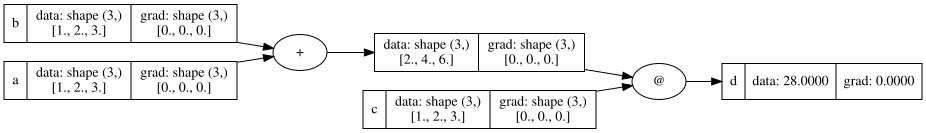

In [ ]:
draw_dot(d)

In [ ]:
d._prev

{Tensor([1. 2. 3.]), Tensor([2. 4. 6.])}

In [ ]:
d._op

'@'

In [ ]:
a = Tensor([[1], [2]]); a.label = 'a'
b = Tensor([[1, 2, 3]]); b.label = 'b'
c = Tensor([[1, 0, 0], [0, 1, 0]]); c.label = 'c'
d = a @ b; d.label = 'd'
e = c + d; e.label = 'e'
f = Tensor([[1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 1, 1]]); f.label = 'f'
L = e @ f; L.label = 'L'
L

Tensor([[ 7.  7.  7.  7.]
 [13. 13. 13. 13.]])

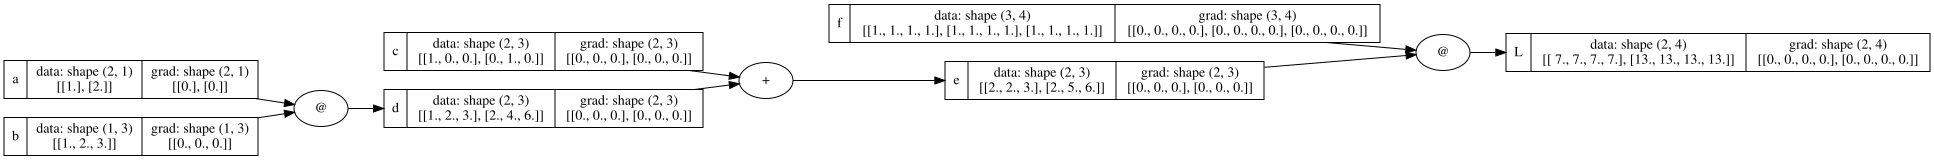

In [ ]:
draw_dot(L)

## 3. Manual Backpropagation

In [ ]:
L.grad = Tensor(np.ones_like(L.data))
L.grad

Tensor([[1. 1. 1. 1.]
 [1. 1. 1. 1.]])

In [ ]:
# dL/de = ?
# L.grad shape = (2,4), e.grad shape = (2,3) f.grad shape = (3,4)
# dL/de = L.grad @ f.transpose()

e.grad = L.grad @ f.transpose()
e.grad

Tensor([[4. 4. 4.]
 [4. 4. 4.]])

In [ ]:
# dL/df = ?
# L.grad shape = (2,4), e.grad shape = (2,3) f.grad shape = (3,4)
# dL/df = e.transpose() @ L.grad

f.grad = e.transpose() @ L.grad
f.grad

Tensor([[4. 4. 4. 4.]
 [7. 7. 7. 7.]
 [9. 9. 9. 9.]])

In [ ]:
# dL/dc = ?
# same as with numbers -> c.grad = e.grad * 1.0

c.grad = e.grad * 1.0
c.grad

Tensor([[4. 4. 4.]
 [4. 4. 4.]])

In [ ]:
d.grad = e.grad * 1.0
d.grad

Tensor([[4. 4. 4.]
 [4. 4. 4.]])

In [ ]:
# dL/da = ?
# a.grad = d.grad @ b.transpose()

a.grad = d.grad @ b.transpose()
a.grad

Tensor([[24.]
 [24.]])

In [ ]:
# dL/db = ?
# b.grad = a.transpose() @ d.grad

b.grad = a.transpose() @ d.grad
b.grad

Tensor([[12. 12. 12.]])

## 4. Automating Backpropagation

In [ ]:
class Tensor:
  def __init__(self, data, _children=(), _op=''):
    self.data = np.array(data, dtype=np.float32)
    self.grad = np.zeros_like(self.data)
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op

  def __repr__(self):
    return f"Tensor({self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data + other.data, (self, other), "+")

    def _backward():
      self.grad += out.grad * 1.0
      other.grad += out.grad * 1.0
    out._backward = _backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data * other.data, (self, other), "*")

    def _backward():
      self.grad += out.grad * other.data
      other.grad += out.grad * self.data

    out._backward = _backward
    return out

  def __matmul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data @ other.data, (self, other), "@")

    def _backward():
      self.grad += out.grad @ other.data.T
      other.grad += self.data.T @ out.grad
    out._backward = _backward
    return out

  def __neg__(self):
    return Tensor(self.data * -1, (self,), "neg")

  def __sub__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data - other.data, (self, other), "-")
    return out

  def __truediv__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data / other.data, (self, other), "/")
    return out

  def transpose(self):
    out = Tensor(self.data.T, (self,), "T")
    return out

In [ ]:
a = Tensor([[1], [2]])
b = Tensor([[1, 2, 3]])
c = Tensor([[1, 0, 0], [0, 1, 0]])
d = a @ b
e = c + d
f = Tensor([[1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 1, 1]])
L = e @ f
L

Tensor([[ 7.  7.  7.  7.]
 [13. 13. 13. 13.]])

In [ ]:
L.grad = np.ones_like(L.data)
L._backward()

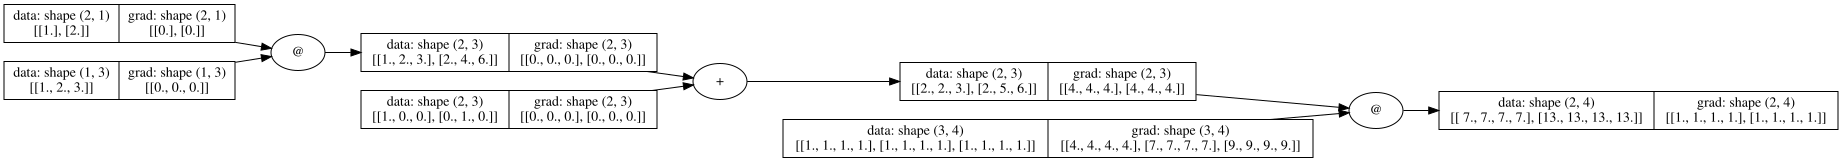

In [ ]:
draw_dot(L)

In [ ]:
# Topological Sort
#
# We are using topological sort L->R as we want to get graph elements from left to right inside a list
# and each element only comes after its inputs
# That way we can automate backpropagation
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)

build_topo(L)
topo

[Tensor([[1. 0. 0.]
  [0. 1. 0.]]),
 Tensor([[1.]
  [2.]]),
 Tensor([[1. 2. 3.]]),
 Tensor([[1. 2. 3.]
  [2. 4. 6.]]),
 Tensor([[2. 2. 3.]
  [2. 5. 6.]]),
 Tensor([[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]),
 Tensor([[ 7.  7.  7.  7.]
  [13. 13. 13. 13.]])]

In [357]:
def unbroadcast(grad, shape):
  """Reduces a broadcasted gradient back to the original shape.

  Args:
    grad: The broadcasted gradient, shaped like the output of the forward
      operation.
    shape: The original shape of the operand that was broadcasted.

  Returns:
    The reduced gradient, shaped like ``shape``.
  """

  while len(grad.shape) > len(shape):
    grad = grad.sum(axis=0)
  for axis, size in enumerate(shape):
    if size == 1:
      grad = grad.sum(axis=axis, keepdims=True)
  return grad

In [358]:
class Tensor:
  def __init__(self, data, _children=(), _op=''):
    self.data = np.array(data, dtype=np.float32)
    self.grad = np.zeros_like(self.data)
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op

  def __repr__(self):
    return f"Tensor({self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data + other.data, (self, other), "+")

    def _backward():
      self.grad += unbroadcast(out.grad, self.data.shape)
      other.grad += unbroadcast(out.grad, other.data.shape)
    out._backward = _backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data * other.data, (self, other), "*")

    def _backward():
      self.grad += unbroadcast(out.grad * other.data, self.data.shape)
      other.grad += unbroadcast(out.grad * self.data, other.data.shape)

    out._backward = _backward
    return out

  def __matmul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data @ other.data, (self, other), "@")

    def _backward():
      self.grad += out.grad @ other.data.T
      other.grad += self.data.T @ out.grad
    out._backward = _backward
    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Tensor(self.data**other, (self,), f"**{other}")

    def _backward():
      self.grad += out.grad * (other * self.data**(other-1))
    out._backward = _backward
    return out

  def __neg__(self):
    out = Tensor(self.data * -1, (self,), "neg")

    def _backward():
      self.grad += -out.grad
    out._backward = _backward
    return out

  def __sub__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data - other.data, (self, other), "-")

    def _backward():
      self.grad += unbroadcast(out.grad, self.data.shape)
      other.grad += unbroadcast(-out.grad, other.data.shape)
    out._backward = _backward
    return out

  def __truediv__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data / other.data, (self, other), "/")

    def _backward():
      self.grad += unbroadcast(out.grad / other.data, self.data.shape)
      other.grad += unbroadcast(-out.grad * self.data / other.data**2, other.data.shape)
    out._backward = _backward
    return out

  def transpose(self):
    out = Tensor(self.data.T, (self,), "T")

    def _backward():
      self.grad += out.grad.T
    out._backward = _backward
    return out

  def sum(self):
    out = Tensor(self.data.sum(), (self,), "sum")

    def _backward():
      self.grad += out.grad
    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)

    build_topo(self)

    self.grad = np.ones_like(self.data)
    for node in reversed(topo):
      node._backward()

  def relu(self):
    out = Tensor(np.maximum(self.data, 0), (self,), "ReLU")
    def _backward():
      self.grad += out.grad * (self.data > 0)
    out._backward = _backward
    return out

  def tanh(self):
    out = Tensor(np.tanh(self.data), (self,), "tanh")
    def _backward():
      self.grad += out.grad * (1 - out.data ** 2)
    out._backward = _backward
    return out

In [359]:
a = Tensor([[1], [2]])
b = Tensor([[1, 2, 3]])
c = Tensor([[1, 0, 0], [0, 1, 0]])
d = a @ b
e = c + d
f = Tensor([[1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 1, 1]])
L = e @ f
L

Tensor([[ 7.  7.  7.  7.]
 [13. 13. 13. 13.]])

In [360]:
L.backward()

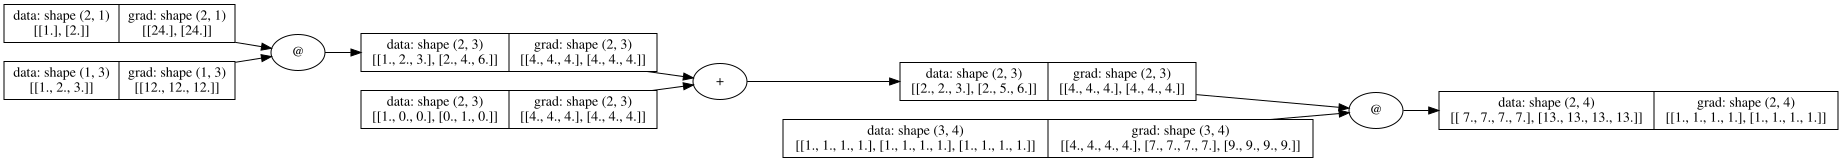

In [361]:
draw_dot(L)

## 5. Backpropagation on Tensors in PyTorch

In [362]:
import torch

a = torch.tensor([[1.0], [2.0]], requires_grad=True)
b = torch.tensor([[1.0, 2.0, 3.0]], requires_grad=True)
c = torch.tensor([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]], requires_grad=True)
d = a @ b
e = c + d
f = torch.tensor([[1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0]], requires_grad=True)
L = e @ f

L.backward(torch.ones_like(L))

print('---')
print("a.grad:\n", a.grad)
print("b.grad:\n", b.grad)
print("c.grad:\n", c.grad)
print("f.grad:\n", f.grad)

---
a.grad:
 tensor([[24.],
        [24.]])
b.grad:
 tensor([[12., 12., 12.]])
c.grad:
 tensor([[4., 4., 4.],
        [4., 4., 4.]])
f.grad:
 tensor([[4., 4., 4., 4.],
        [7., 7., 7., 7.],
        [9., 9., 9., 9.]])


In [363]:
a = Tensor([1, 2, 3])
a

Tensor([1. 2. 3.])

In [364]:
a.tanh()

Tensor([0.7615942 0.9640276 0.9950548])

## 6. Building MLP using Tensor Class

In [391]:
class TensorNeuron:
  def __init__(self, input_size: int):
    self.w = Tensor(np.random.uniform(low=-1, high=1, size=(input_size, 1)).flatten())
    self.b = Tensor(np.random.uniform(low=-1, high=1))

  def __call__(self, x):
    if not isinstance(x, Tensor):
      x = Tensor(x)
    act = (x * self.w).sum() + self.b
    out = act.tanh()
    out.data = out.data.flatten()
    return out

  def parameters(self):
    return [self.w, self.b]

In [392]:
x = [1, 2, 3]
n = TensorNeuron(3)

n.w

Tensor([ 0.06517174 -0.9509604   0.4707502 ])

In [393]:
n(x)._prev

{Tensor(0.016727149486541748)}

In [394]:
n.parameters()

[Tensor([ 0.06517174 -0.9509604   0.4707502 ]), Tensor(0.4412255883216858)]

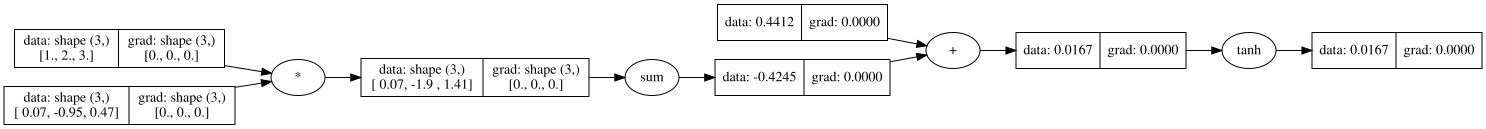

In [395]:
draw_dot(n(x))

In [396]:
class TensorLayer:
  def __init__(self, input_size: int, output_size: int):
    self.w = Tensor(np.random.uniform(-1, 1, size=(input_size, output_size)))
    self.b = Tensor(np.random.uniform(-1, 1, size=output_size))

  def __call__(self, x):
    if not isinstance(x, Tensor):
      x = Tensor(x)
    outs = x @ self.w + self.b
    return outs

  def parameters(self):
    return [self.w, self.b]

In [397]:
x = [1, 2]
n = TensorLayer(2,3)

n(x)

Tensor([2.2708805  0.30338562 1.0726365 ])

In [399]:
n.parameters()

[Tensor([[-0.30781582  0.996134    0.22661021]
  [ 0.82636356 -0.46042493 -0.05395364]]),
 Tensor([0.9259692  0.2281015  0.95393354])]

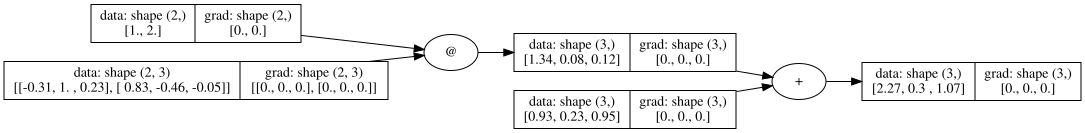

In [400]:
draw_dot(n(x))

In [402]:
from typing import List

class TensorMLP:
  def __init__(self, input_size: int, output_sizes: List[int]):
    sz = [input_size] + output_sizes
    self.layers = [TensorLayer(sz[i], sz[i+1]) for i in range(len(output_sizes))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)

    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [403]:
x = [1, 2, 3]
n = TensorMLP(3, [4, 4, 1])

n(x)

Tensor([6.5561476])

In [404]:
n.parameters()

[Tensor([[ 0.26332045  0.07875079  0.54101783  0.3124813 ]
  [-0.29134595  0.7204644   0.7337917   0.6236092 ]
  [ 0.94371337  0.40840697  0.67332166 -0.57557756]]),
 Tensor([ 0.5794336   0.8429721  -0.5824765  -0.24579713]),
 Tensor([[ 0.11427213  0.8839767  -0.00377569  0.9966799 ]
  [ 0.7395315   0.83197826 -0.88109475  0.89566594]
  [-0.8345805   0.69744146  0.8322157   0.32464153]
  [-0.11955293 -0.9235979   0.06503715 -0.07846087]]),
 Tensor([-0.23083664  0.11268067  0.14142655  0.9908029 ]),
 Tensor([[-0.62394214]
  [-0.09986714]
  [-0.37768304]
  [ 0.8859556 ]]),
 Tensor([-0.1614992])]

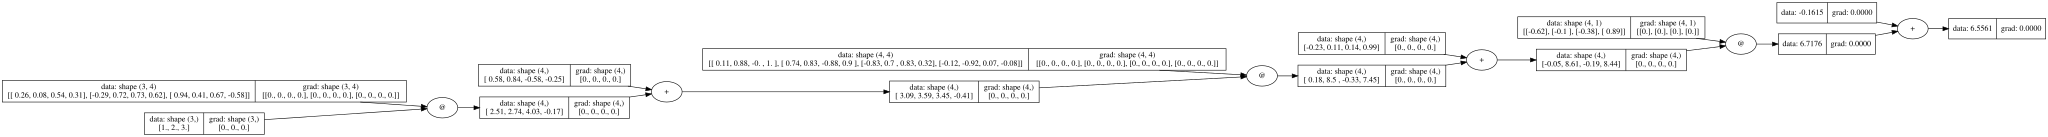

In [405]:
draw_dot(n(x))

In [406]:
xs = Tensor([
    [2, 3, -1],
    [3, -1, 0.5],
    [0.5, 1, 1],
    [1, 1, -1]
])

ys = Tensor([[1], [-1], [-1], [1]])

In [407]:
ypreds = n(xs)
ypreds

Tensor([[2.9477758]
 [2.9261074]
 [3.4158204]
 [1.3292613]])

In [408]:
# MSE Loss
loss = (ypreds - ys)**2
loss

Tensor([[ 3.7938306]
 [15.414319 ]
 [19.499468 ]
 [ 0.108413 ]])

In [409]:
loss.sum()

Tensor(38.81603240966797)

In [410]:
loss.backward()

In [411]:
n.layers[0].w.grad

array([[26.400942  , 21.189741  , 15.456903  ,  2.649886  ],
       [ 9.65848   ,  7.7520223 ,  5.6547303 ,  0.96943027],
       [ 5.9465203 ,  4.7727547 ,  3.4814963 ,  0.5968576 ]],
      dtype=float32)

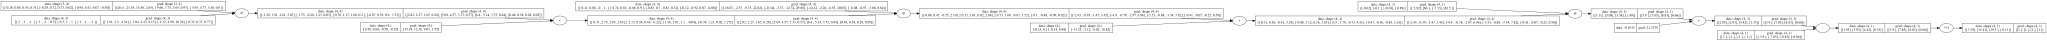

In [412]:
draw_dot(loss)